In [1]:
import numpy as np
import xarray as xr
import pandas as pd
import skill_metrics as sm
import warnings
from glob import glob

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
import cartopy
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmcrameri.cm as cm
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
import cartopy.mpl.geoaxes as cgeo

warnings.filterwarnings("ignore")

In [2]:
# Constants

START_DATE = np.datetime64('2000-10-01T00:00:00.000000000')
END_DATE = np.datetime64('2015-09-29T23:00:00.000000000')
# START_DATE = np.datetime64('2000-01-01T00:00:00.000000000')
# END_DATE = np.datetime64('2010-12-31T23:00:00.000000000')
N_HOURS = (END_DATE - START_DATE) / np.timedelta64(1, 'h') + 1
N_DAYS = np.round((END_DATE - START_DATE) / np.timedelta64(1, 'D'))
print(N_HOURS, N_DAYS)

COVERAGE_THRESHOLD = 0.9
ZSCORE_THRESHOLD = 5  # for outlier detection; may want to adjust (this seems to reject some plausible Wind Spd values, for instance)
vars = [
    "Wind Spd (km/h)",
]

BAD_MONTHS = [[2005, 4],
             [2005, 7],
             [2005, 10],
             [2006, 3],
             [2006, 9],
             [2008, 7],
             [2015, 10],
             [2017, 8],
             [2017, 11],
             [2019, 9],
             [2021, 7],
             [2022, 2],
             [2023, 6]]

full_time_index = pd.Index(
    np.arange(START_DATE, END_DATE + np.timedelta64(1, 'h'), np.timedelta64(1, 'h')),
    name='Date/Time (LST)'
    )

131448.0 5477.0


In [3]:
def readable_time_coord(ds, time_var='Times'):

    time_vals = ds[time_var].values

    # Extract integer (YYYYMMDD) and fractional day parts
    dates_int = time_vals.astype(int)
    frac_days = time_vals - dates_int

    # Parse integers to datetime
    base_dates = pd.to_datetime(dates_int.astype(str), format="%Y%m%d")

    # Add fractional day as timedelta
    full_times = base_dates + pd.to_timedelta(frac_days, unit="D")
    full_times = full_times.round("1h")

    # Assign back to dataset
    ds = ds.assign_coords({time_var: full_times})
    ds = ds.transpose(time_var, ...)

    ds = ds.rename({time_var: "time"})
    
    return ds

# Find the nearest grid point in winds_ds to the station's lat/lon
def get_nearest_wrf_point(ds, lat, lon):
    abs_lat = np.abs(ds['XLAT'] - lat)
    abs_lon = np.abs(ds['XLONG'] - lon)
    dist = abs_lat + abs_lon
    # Find indices of the minimum distance
    idx = np.unravel_index(np.argmin(dist.values), dist.shape)
    return idx

# Open WRF Data

In [4]:
# UBC WRF

wrf_ubc_static = xr.open_mfdataset("/users/rpayne/data/unproc/WRF-UBC/ubc_wrf_staticfields_d03.nc")
wrf_ubc_static['HGT'] = np.clip(wrf_ubc_static['HGT'], 0., None)
hgt_ubc = wrf_ubc_static['HGT'].values.squeeze()
landmask_ubc = wrf_ubc_static['LANDMASK'].values.squeeze()
lon_ubc = wrf_ubc_static['XLONG'].values.squeeze()
lat_ubc = wrf_ubc_static['XLAT'].values.squeeze()

winds_ds = readable_time_coord(xr.open_dataset("/users/rpayne/data/unproc/WRF-UBC/WS10/WS10_dailymean_199910_202309.nc"))
winds_ds = winds_ds.sel(time=slice(START_DATE, END_DATE)).drop_vars('Times_bnds')

# USask WRF

wrf_usask_static = xr.open_mfdataset("/users/rpayne/data/unproc/WRF-USASK/ctl/HGT_ubcgrid.nc")
wrf_usask_static['HGT'] = np.clip(wrf_usask_static['HGT'], 0., None)
hgt_usask = wrf_usask_static['HGT'].values.squeeze()

winds_ds_usask = xr.open_dataset("/users/rpayne/data/unproc/WRF-USASK/ctl/WS10/merged/WS10_dailymean_regrid_200010_201509.nc")
winds_ds_usask = winds_ds_usask.sel(time=slice(START_DATE, END_DATE)).drop_vars('time_bnds')

# Open STN Data

In [5]:
# Takes ~5 minutes to run

wx_data_fnames = sorted(glob("/users/rpayne/data/unproc/STN_ECCC/api/hourly/ec_*.csv"))
df = pd.concat(
    (pd.read_csv(f, encoding='utf8', low_memory=True) for f in wx_data_fnames),
    ignore_index=True
)
df['Date/Time (LST)'] = pd.to_datetime(df['Date/Time (LST)'], format='%Y-%m-%d %H:%M:%S')
df = df[df['Date/Time (LST)'] >= START_DATE]  # Filter for data to align w WRF
df = df[df['Date/Time (LST)'] <= END_DATE]
df.set_index('Date/Time (LST)', inplace=True)
df

,Longitude (x),Latitude (y),Station Name,Climate ID,Year,Month,Day,Time (LST),Flag,Temp (°C),...,Visibility Flag,Stn Press (kPa),Stn Press Flag,Hmdx,Hmdx Flag,Wind Chill,Wind Chill Flag,Weather,Precip. Amount (mm),Precip. Amount Flag
Date/Time (LST),,,,,,,,,,,,,,,,,,,,,
2000-10-01 00:00:00,-115.07,51.08,BOW VALLEY,3050778,2000,10,1,00:00,NaN,-2.3,...,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-10-01 01:00:00,-115.07,51.08,BOW VALLEY,3050778,2000,10,1,01:00,NaN,-1.8,...,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-10-01 02:00:00,-115.07,51.08,BOW VALLEY,3050778,2000,10,1,02:00,NaN,-1.2,...,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-10-01 03:00:00,-115.07,51.08,BOW VALLEY,3050778,2000,10,1,03:00,NaN,-0.2,...,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2000-10-01 04:00:00,-115.07,51.08,BOW VALLEY,3050778,2000,10,1,04:00,NaN,0.3,...,M,NaN,M,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2015-09-29 19:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2015,9,29,19:00,NaN,12.1,...,NaN,96.07,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2015-09-29 20:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2015,9,29,20:00,NaN,10.9,...,NaN,96.13,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
2015-09-29 21:00:00,-119.65,49.56,SUMMERLAND CS,112G8L1,2015,9,29,21:00,NaN,9.9,...,NaN,96.15,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN


In [6]:
# Create a dictionary mapping station name to (lat, lon) from df
stn_latlon = {}
stns = df["Station Name"].unique()
for stn in stns:
    stn_rows = df[df["Station Name"] == stn]
    if not stn_rows.empty:
        lat = stn_rows["Latitude (y)"].iloc[0]
        lon = stn_rows["Longitude (x)"].iloc[0]
        stn_latlon[stn] = (lat, lon)
    else:
        stn_latlon[stn] = (None, None)


def get_stn(stn_name, data=df):
    stn = data[data["Station Name"] == stn_name]
    stn = stn.sort_index()
    stn = stn[~stn.index.duplicated(keep='last')]
    stn = stn.reindex(full_time_index)
    return stn

In [7]:
# Find all stations that meet the coverage threshold for the given variables

WS_coverage_dict = {}
stns_outside_domain = ['GARDEN RIVER', 'COLD LAKE A'] # stns that fall outside the UBC WRF domain

for i,stn in enumerate(stns):
    print(f"{i+1}/{len(stns)}")
    
    if stn not in stns_outside_domain:

        stn_data = get_stn(stn)

        WS_data = stn_data["Wind Spd (km/h)"].resample('D').mean()

        WS_coverage = np.count_nonzero(~np.isnan(WS_data)) / N_DAYS
        if WS_coverage >= COVERAGE_THRESHOLD:
            WS_coverage_dict[stn] = WS_coverage

WS_stns = np.sort(list(WS_coverage_dict.keys()))

print(f"Number of stations with adequate Wind Speed coverage: {len(WS_coverage_dict)}")

1/364
2/364
3/364
4/364
5/364
6/364
7/364
8/364
9/364
10/364
11/364
12/364
13/364
14/364
15/364
16/364
17/364
18/364
19/364
20/364
21/364
22/364
23/364
24/364
25/364
26/364
27/364
28/364
29/364
30/364
31/364
32/364
33/364
34/364
35/364
36/364
37/364


38/364
39/364
40/364
41/364
42/364
43/364
44/364
45/364
46/364
47/364
48/364
49/364
50/364
51/364
52/364
53/364
54/364
55/364
56/364
57/364
58/364
59/364
60/364
61/364
62/364
63/364
64/364
65/364
66/364
67/364
68/364
69/364
70/364
71/364
72/364
73/364
74/364
75/364
76/364
77/364
78/364
79/364
80/364
81/364
82/364
83/364
84/364
85/364
86/364
87/364
88/364
89/364
90/364
91/364
92/364
93/364
94/364
95/364
96/364
97/364
98/364
99/364
100/364
101/364
102/364
103/364
104/364
105/364
106/364
107/364
108/364
109/364
110/364
111/364
112/364
113/364
114/364
115/364
116/364
117/364
118/364
119/364
120/364
121/364
122/364
123/364
124/364
125/364
126/364
127/364
128/364
129/364
130/364
131/364
132/364
133/364
134/364
135/364
136/364
137/364
138/364
139/364
140/364
141/364
142/364
143/364
144/364
145/364
146/364
147/364
148/364
149/364
150/364
151/364
152/364
153/364
154/364
155/364
156/364
157/364
158/364
159/364
160/364
161/364
162/364
163/364
164/364
165/364
166/364
167/364
168/364
169/364
170/36

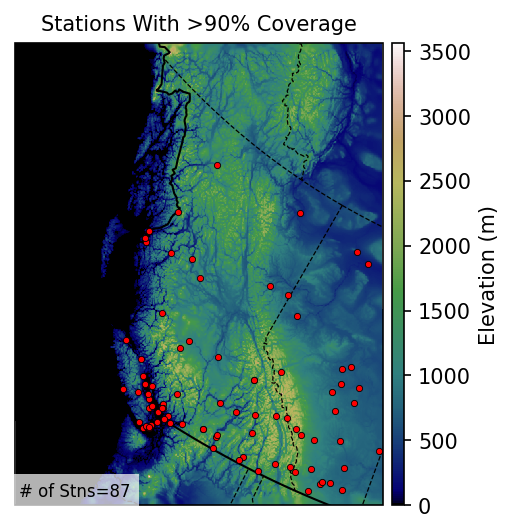

In [8]:
# Create a figure
proj = ccrs.Stereographic(
    central_latitude=90.0,
    central_longitude=wrf_ubc_static.STAND_LON,
    true_scale_latitude=wrf_ubc_static.TRUELAT1,
)
hgt_ubc = wrf_ubc_static['HGT'].values.squeeze()
lon_ubc = wrf_ubc_static['XLONG'].values.squeeze()
lat_ubc = wrf_ubc_static['XLAT'].values.squeeze()
fig, ax = plt.subplots(subplot_kw={"projection": proj},figsize=(4,4),dpi=150)
cmap =  ListedColormap(plt.cm.gist_earth(np.linspace(0, 1, 256)))

# Plot using pcolormesh
mesh = ax.pcolormesh(lon_ubc, lat_ubc, hgt_ubc, transform=ccrs.PlateCarree(), shading='auto', cmap=cmap)
ax.add_feature(cfeature.BORDERS, linewidth=1, zorder=1)   # Country borders
provinc_bodr = cartopy.feature.NaturalEarthFeature(category='cultural', 
    name='admin_1_states_provinces_lines', scale='50m', facecolor='none', edgecolor='k', zorder=1)
ax.add_feature(provinc_bodr, linestyle='--', linewidth=0.6, edgecolor="k", zorder=1)

for i,stn in enumerate(WS_coverage_dict.keys()):
    lat, lon = stn_latlon[stn]
    ax.scatter(lon, lat, marker='.', facecolor='red', edgecolor='k', linewidth=.4, transform=ccrs.PlateCarree())
    # ax.text(lon, lat, stn, fontsize=3, transform=ccrs.PlateCarree(), zorder=3, va='bottom', ha='right',color='red')

ax.set_title(f"Stations With >{100*COVERAGE_THRESHOLD:.0f}% Coverage", fontsize=10)
ax.text(0.01, 0.01, f"# of Stns={len(WS_coverage_dict)}", transform=ax.transAxes, fontsize=8, va='bottom', ha='left', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none'))

cbar = plt.colorbar(mesh, ax=ax, orientation='vertical', pad=0.02, aspect=40)
cbar.set_label('Elevation (m)')
plt.show()

# Analysis

In [9]:
# Create an index for the pd dataframe that ranges over the entire period
# by START_DATE and END_DATE:

full_time_index = pd.Index(
    np.arange(START_DATE, END_DATE + np.timedelta64(1, 'h'), np.timedelta64(1, 'h')),
    name='Date/Time (LST)'
    )

def sort_data(data, lats, lons):
    sorted_indices = np.argsort(np.abs(data))
    lons = [lons[i] for i in sorted_indices]
    lats = [lats[i] for i in sorted_indices]
    data = [data[i] for i in sorted_indices]
    return data, lats, lons

In [10]:
def calc_station_metrics(winds_ds, ufactor_mod= 3.6, ufactor_stn = 1):

    # Initialize dictionaries to hold results for each season and annual
    corr_dict = {'DJF': {}, 'MAM': {}, 'JJA': {}, 'SON': {}, 'ANN': {}}
    bmean_dict = {'DJF': {}, 'MAM': {}, 'JJA': {}, 'SON': {}, 'ANN': {}}
    bmedian_dict = {'DJF': {}, 'MAM': {}, 'JJA': {}, 'SON': {}, 'ANN': {}}
    b95p_dict = {'DJF': {}, 'MAM': {}, 'JJA': {}, 'SON': {}, 'ANN': {}}

    # Define months for each season
    seasons = {
        'DJF': [12, 1, 2],
        'MAM': [3, 4, 5],
        'JJA': [6, 7, 8],
        'SON': [9, 10, 11]
    }

    for i, stn in enumerate(WS_coverage_dict.keys()):
        print(f"({i+1}/{len(WS_coverage_dict)}) Working on {stn}...")

        data = get_stn(stn)
        lat, lon = stn_latlon[stn]
        stn_winds = data["Wind Spd (km/h)"].resample('D').mean()
        stn_winds = stn_winds[stn_winds.index < '2023-10-01']

        for year, month in BAD_MONTHS:
            stn_winds = stn_winds[~((stn_winds.index.year == year) & (stn_winds.index.month == month))]

        nearest_idx = get_nearest_wrf_point(winds_ds, lat, lon)
        wrf_winds = winds_ds.isel(south_north=nearest_idx[0], west_east=nearest_idx[1])
        for year, month in BAD_MONTHS:
            wrf_winds = wrf_winds.sel(time=~((wrf_winds.time.dt.year == year) & (wrf_winds.time.dt.month == month)))

        for season, months in seasons.items():
            stn_season = stn_winds[stn_winds.index.month.isin(months)].values * ufactor_stn
            wrf_season = wrf_winds.sel(time=wrf_winds.time.dt.month.isin(months))['WS10'].values * ufactor_mod
            mask = ~np.isnan(stn_season)
            a, b = stn_season[mask], wrf_season[mask]
            stn_season, wrf_season = None, None
            if len(a) == 0 or len(b) == 0:
                print(f"{season}: ERROR WITH STATION {stn}: No valid data")
                continue
            try:
                corr_dict[season][(lat, lon)] = np.corrcoef(a, b)[0, 1]
                bmean_dict[season][(lat, lon)] = np.mean(b) - np.mean(a)
                bmedian_dict[season][(lat, lon)] = np.median(b) - np.median(a)
                b95p_dict[season][(lat, lon)] = np.percentile(b, 95) - np.percentile(a, 95)
            except Exception as e:
                print(f"{season}: ERROR WITH STATION {stn}: {e}")
                continue

        stn_ann = stn_winds.values * ufactor_stn
        wrf_ann = wrf_winds['WS10'].values * ufactor_mod
        mask_ann = ~np.isnan(stn_ann)
        a_ann, b_ann = stn_ann[mask_ann], wrf_ann[mask_ann]
        stn_ann, wrf_ann = None, None
        if len(a_ann) == 0 or len(b_ann) == 0:
            print(f"ANN: ERROR WITH STATION {stn}: No valid data")
            continue
        try:
            corr_dict['ANN'][(lat, lon)] = np.corrcoef(a_ann, b_ann)[0, 1]
            bmean_dict['ANN'][(lat, lon)] = np.mean(b_ann) - np.mean(a_ann)
            bmedian_dict['ANN'][(lat, lon)] = np.median(b_ann) - np.median(a_ann)
            b95p_dict['ANN'][(lat, lon)] = np.percentile(b_ann, 95) - np.percentile(a_ann, 95)
        except Exception as e:
            print(f"ANN: ERROR WITH STATION {stn}: {e}")
            continue

    print("DONE.")
    return corr_dict, bmean_dict, bmedian_dict, b95p_dict

In [11]:
corr_dict_ubc, bmean_dict_ubc, bmedian_dict_ubc, b95p_dict_ubc = calc_station_metrics(winds_ds, ufactor_mod=3.6, ufactor_stn=1.)
corr_dict_usask, bmean_dict_usask, bmedian_dict_usask, b95p_dict_usask = calc_station_metrics(winds_ds_usask, ufactor_mod=3.6, ufactor_stn=1.)

(1/87) Working on BOW VALLEY...


(2/87) Working on JASPER WARDEN...
(3/87) Working on ESTHER 1...
(4/87) Working on DRUMHELLER EAST...
(5/87) Working on CROWSNEST...
(6/87) Working on LACOMBE CDA 2...
(7/87) Working on BOW ISLAND...
(8/87) Working on BRETON PLOTS...
(9/87) Working on CAMROSE...
(10/87) Working on ELK ISLAND NAT PARK...
(11/87) Working on BROOKS...
(12/87) Working on CLARESHOLM...
(13/87) Working on LETHBRIDGE A...
(14/87) Working on LETHBRIDGE CDA...
(15/87) Working on CARDSTON...
(16/87) Working on GRANDE PRAIRIE A...
(17/87) Working on HIGH LEVEL A...
(18/87) Working on BANFF CS...
(19/87) Working on EDMONTON STONY PLAIN CS...
(20/87) Working on FORT VERMILION...
(21/87) Working on BARRHEAD CS...
(22/87) Working on BARNWELL AGDM...
(23/87) Working on DAPP AGDM...
(24/87) Working on COP UPPER...
(25/87) Working on OSOYOOS CS...
(26/87) Working on PENTICTON A...
(27/87) Working on PRINCETON A...
(28/87) Working on KELP REEFS...
(29/87) Working on RACE ROCKS...
(30/87) Working on VICTORIA HARBOUR A...


# Plotting

In [12]:
def plot_annual(metric_dict, cmap, topo, hist_bins, hist_ylim=None, hist_yticks=[], hist_xlabel=None, cbar_label=None, cbar_ticks=None):
    # Create a figure
    proj = ccrs.Stereographic(
        central_latitude=90.0,
        central_longitude=wrf_ubc_static.STAND_LON,
        true_scale_latitude=wrf_ubc_static.TRUELAT1,
    )
    lon_ubc = wrf_ubc_static['XLONG'].values.squeeze()
    lat_ubc = wrf_ubc_static['XLAT'].values.squeeze()
    fig, ax = plt.subplots(subplot_kw={"projection": proj}, figsize=(4, 4), dpi=150)

    # Plot using pcolormesh
    mesh = ax.pcolormesh(lon_ubc, lat_ubc, topo, transform=ccrs.PlateCarree(), shading='auto', cmap='Greys')
    ax.coastlines(linewidth=0.5, zorder=1)
    ax.add_feature(cfeature.BORDERS, linewidth=.6, zorder=1)
    provinc_bodr = cartopy.feature.NaturalEarthFeature(
        category='cultural',
        name='admin_1_states_provinces_lines',
        scale='50m',
        facecolor='none',
        edgecolor='k',
        zorder=1
    )
    ax.add_feature(provinc_bodr, linestyle='--', linewidth=0.5, edgecolor="k", zorder=1)

    # Plot the station metrics
    stn_lons = []
    stn_lats = []
    metrics = []
    for stn_coords, metric in metric_dict['ANN'].items():
        lat, lon = stn_coords
        stn_lats.append(lat)
        stn_lons.append(lon)
        metrics.append(metric)
    metrics, stn_lats, stn_lons = sort_data(metrics, stn_lats, stn_lons)
    scatter = ax.scatter(
        stn_lons, stn_lats,
        c=metrics,
        s=15,
        cmap=cmap,
        edgecolor='k',
        linewidth=0.4,
        marker='o',
        transform=ccrs.PlateCarree(),
        zorder=3,
        vmin=hist_bins[0],
        vmax=hist_bins[-1],
    )

    # histogram
    hist_bins = np.round(hist_bins, 2)
    axins = inset_axes(ax, width="24%", height="24%", loc='upper left', borderpad=0.4)
    axins.hist(metrics, bins=hist_bins, color='gray', edgecolor='black', linewidth=.4)
    axins.set_xlabel(hist_xlabel, fontsize=6, labelpad=.5)
    axins.tick_params(axis='both', which='major', labelsize=6, size=2)
    axins.set_xticks(np.linspace(hist_bins[0], hist_bins[-1], 3))
    axins.set_xticklabels(np.linspace(hist_bins[0], hist_bins[-1], 3), fontsize=5)
    axins.xaxis.set_tick_params(pad=1)
    if hist_ylim is not None:
        axins.set_ylim((0, hist_ylim))
    axins.set_yticks(hist_yticks)
    axins.set_yticklabels(hist_yticks, fontsize=5)
    axins.yaxis.set_tick_params(pad=1)
    axins.yaxis.tick_right()
    axins.yaxis.set_label_position("right")

    print('ANN',f'min={min(metrics):.2f}',f'max={max(metrics):.2f}')

    cbar = plt.colorbar(scatter, ax=ax, orientation='vertical', pad=0.02, aspect=40)
    if cbar_ticks is not None:
        cbar.set_ticks(cbar_ticks)
    cbar.set_label(cbar_label)
    plt.show()

ANN min=0.22 max=0.76


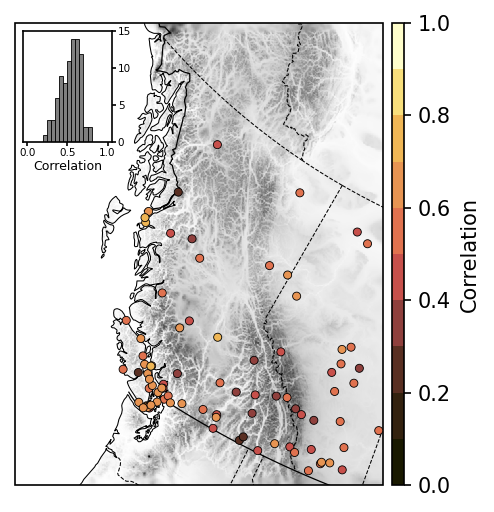

ANN min=-6.40 max=9.99


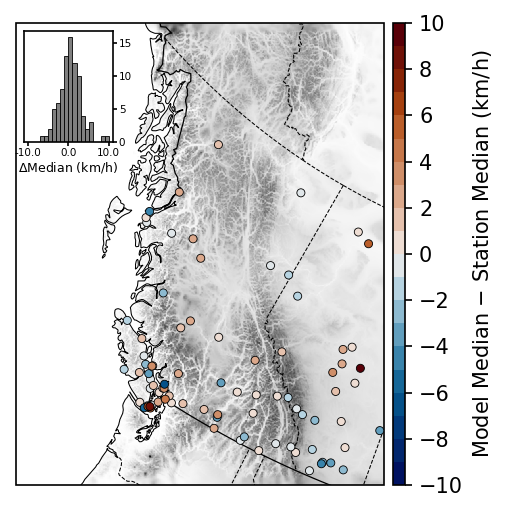

ANN min=-19.87 max=22.77


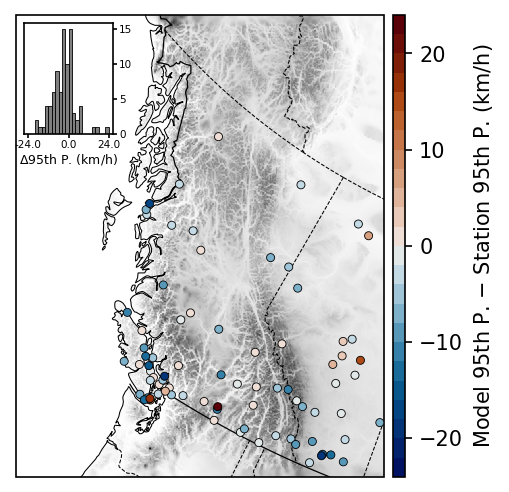

In [13]:
cmap_corr = ListedColormap(cm.lajolla(np.linspace(0, 1, 10)))
cmap_medbias = ListedColormap(cm.vik(np.linspace(0, 1, 20)))
cmap_95pbias = ListedColormap(cm.vik(np.linspace(0, 1, 24)))

plot_annual(corr_dict_ubc, cmap_corr, topo=hgt_ubc, hist_bins=np.arange(0, 1+.05, .05), hist_xlabel="Correlation", cbar_label="Correlation", hist_yticks=[0, 5, 10, 15])
plot_annual(bmedian_dict_ubc, cmap_medbias, topo=hgt_ubc, hist_bins=np.arange(-10,10+1,1), hist_xlabel=r'$\Delta$Median (km/h)', cbar_label='Model Median $-$ Station Median (km/h)', hist_yticks=[0, 5, 10, 15], cbar_ticks=np.arange(-10,12,2))
plot_annual(b95p_dict_ubc, cmap_95pbias, topo=hgt_ubc, hist_bins=np.arange(-24,24+2,2), hist_xlabel=r'$\Delta$95th P. (km/h)', cbar_label='Model 95th P. $-$ Station 95th P. (km/h)', hist_yticks=[0, 5, 10, 15])

ANN min=0.29 max=0.83


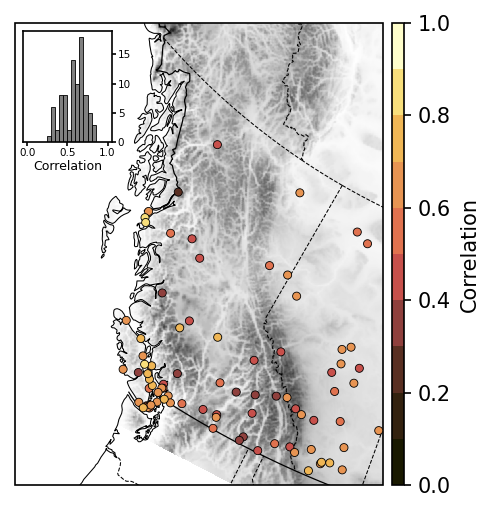

ANN min=-7.05 max=9.92


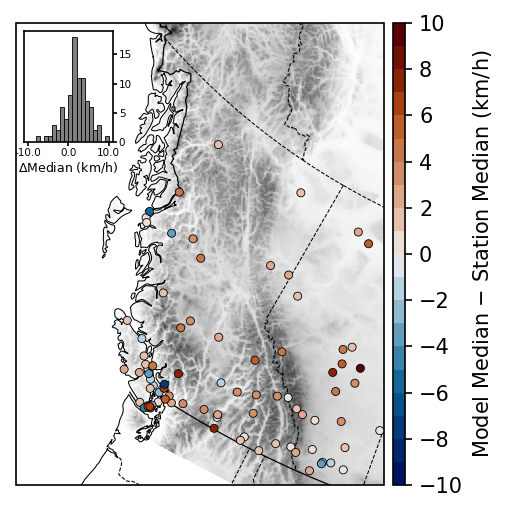

ANN min=-22.11 max=15.32


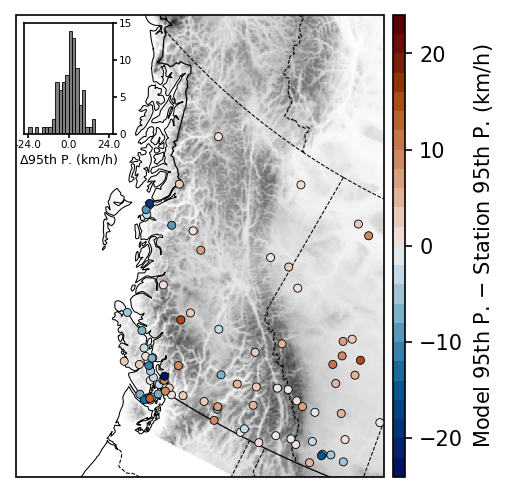

In [14]:
cmap_corr = ListedColormap(cm.lajolla(np.linspace(0, 1, 10)))
cmap_medbias = ListedColormap(cm.vik(np.linspace(0, 1, 20)))
cmap_95pbias = ListedColormap(cm.vik(np.linspace(0, 1, 24)))

plot_annual(corr_dict_usask, cmap_corr, topo=hgt_usask, hist_bins=np.arange(0, 1+.05, .05), hist_xlabel="Correlation", cbar_label="Correlation", hist_yticks=[0, 5, 10, 15])
plot_annual(bmedian_dict_usask, cmap_medbias, topo=hgt_usask, hist_bins=np.arange(-10,10+1,1), hist_xlabel=r'$\Delta$Median (km/h)', cbar_label='Model Median $-$ Station Median (km/h)', hist_yticks=[0, 5, 10, 15], cbar_ticks=np.arange(-10,12,2))
plot_annual(b95p_dict_usask, cmap_95pbias, topo=hgt_usask, hist_bins=np.arange(-24,24+2,2), hist_xlabel=r'$\Delta$95th P. (km/h)', cbar_label='Model 95th P. $-$ Station 95th P. (km/h)', hist_yticks=[0, 5, 10, 15])

In [15]:
def plot_seasonal(metric_dict, cmap, topo, hist_bins, hist_yticks=[], hist_ylim=None, hist_xlabel=None, cbar_label=None):
    seasons = ['DJF', 'MAM', 'JJA', 'SON']
    hist_bins = np.round(hist_bins, 2)
    proj = ccrs.Stereographic(
        central_latitude=90.0,
        central_longitude=wrf_ubc_static.STAND_LON,
        true_scale_latitude=wrf_ubc_static.TRUELAT1,
    )
    hgt_ubc = wrf_ubc_static['HGT'].values.squeeze()
    lon_ubc = wrf_ubc_static['XLONG'].values.squeeze()
    lat_ubc = wrf_ubc_static['XLAT'].values.squeeze()
    fig, axes = plt.subplots(2, 2, subplot_kw={"projection": proj}, figsize=(7.52, 8), dpi=150)
    axes = axes.flatten()

    scatters = []
    for idx, season in enumerate(seasons):
        ax = axes[idx]
        mesh = ax.pcolormesh(lon_ubc, lat_ubc, topo, transform=ccrs.PlateCarree(), shading='auto', cmap='Greys')
        ax.coastlines(linewidth=0.5, zorder=1)
        ax.add_feature(cfeature.BORDERS, linewidth=.6, zorder=1)
        provinc_bodr = cartopy.feature.NaturalEarthFeature(
            category='cultural',
            name='admin_1_states_provinces_lines',
            scale='50m',
            facecolor='none',
            edgecolor='k',
            zorder=1
        )
        ax.add_feature(provinc_bodr, linestyle='--', linewidth=0.5, edgecolor="k", zorder=1)
        ax.text(0.97, 0.97, season, color='red', fontsize=16, ha='right', va='top', transform=ax.transAxes)

        stn_lons, stn_lats, metrics = [], [], []
        for stn_coords, metric in metric_dict.get(season, {}).items():
            lat, lon = stn_coords
            stn_lats.append(lat)
            stn_lons.append(lon)
            metrics.append(metric)
        metrics, stn_lats, stn_lons = sort_data(metrics, stn_lats, stn_lons)
        scatter = ax.scatter(
            stn_lons, stn_lats,
            c=metrics,
            s=15,
            cmap=cmap,
            edgecolor='k',
            linewidth=0.4,
            marker='o',
            transform=ccrs.PlateCarree(),
            zorder=3,
            vmin=hist_bins[0],
            vmax=hist_bins[-1],
        )
        scatters.append(scatter)

        axins = inset_axes(ax, width="24%", height="24%", loc='upper left', borderpad=0.4)
        axins.hist(metrics, bins=hist_bins, color='gray', edgecolor='black', linewidth=.4)
        axins.set_xlabel(hist_xlabel, fontsize=6, labelpad=.5)
        axins.tick_params(axis='both', which='major', labelsize=6, size=2)
        axins.set_xticks(np.linspace(hist_bins[0], hist_bins[-1], 3))
        axins.set_xticklabels(np.linspace(hist_bins[0], hist_bins[-1], 3), fontsize=5)
        axins.xaxis.set_tick_params(pad=1)
        if hist_ylim is not None:
            axins.set_ylim((0, hist_ylim))
        axins.set_yticks(hist_yticks)
        axins.set_yticklabels(hist_yticks, fontsize=5)
        axins.yaxis.set_tick_params(pad=1)
        axins.yaxis.tick_right()
        axins.yaxis.set_label_position("right")

        print(season,f'min={min(metrics):.2f}',f'max={max(metrics):.2f}')

    plt.subplots_adjust(wspace=0., hspace=-0)
    cbar = plt.colorbar(scatters[0], ax=axes, orientation='vertical', pad=0.0075, aspect=70)
    cbar.set_label(cbar_label)
    plt.show()

DJF min=0.08 max=0.82
MAM min=0.28 max=0.75
JJA min=0.17 max=0.74
SON min=0.29 max=0.78


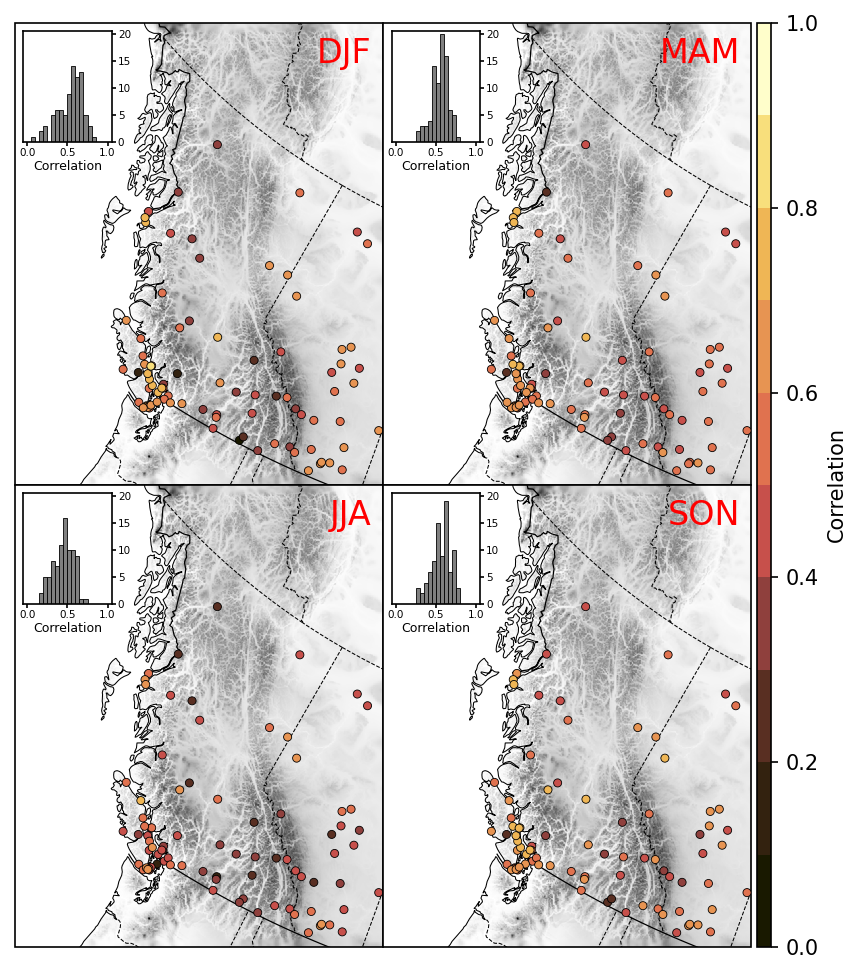

DJF min=-12.59 max=13.73
MAM min=-6.16 max=9.09
JJA min=-9.53 max=8.13
SON min=-7.42 max=10.23


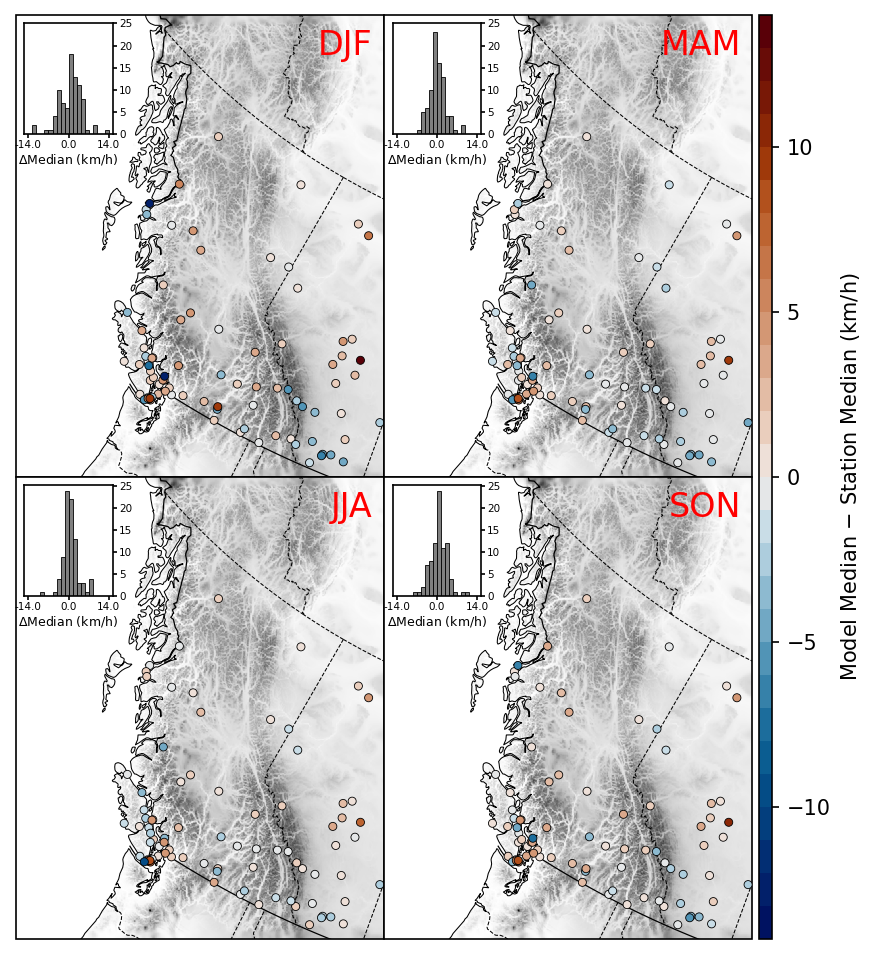

DJF min=-29.62 max=31.09
MAM min=-16.92 max=14.73
JJA min=-15.83 max=16.08
SON min=-18.28 max=21.33


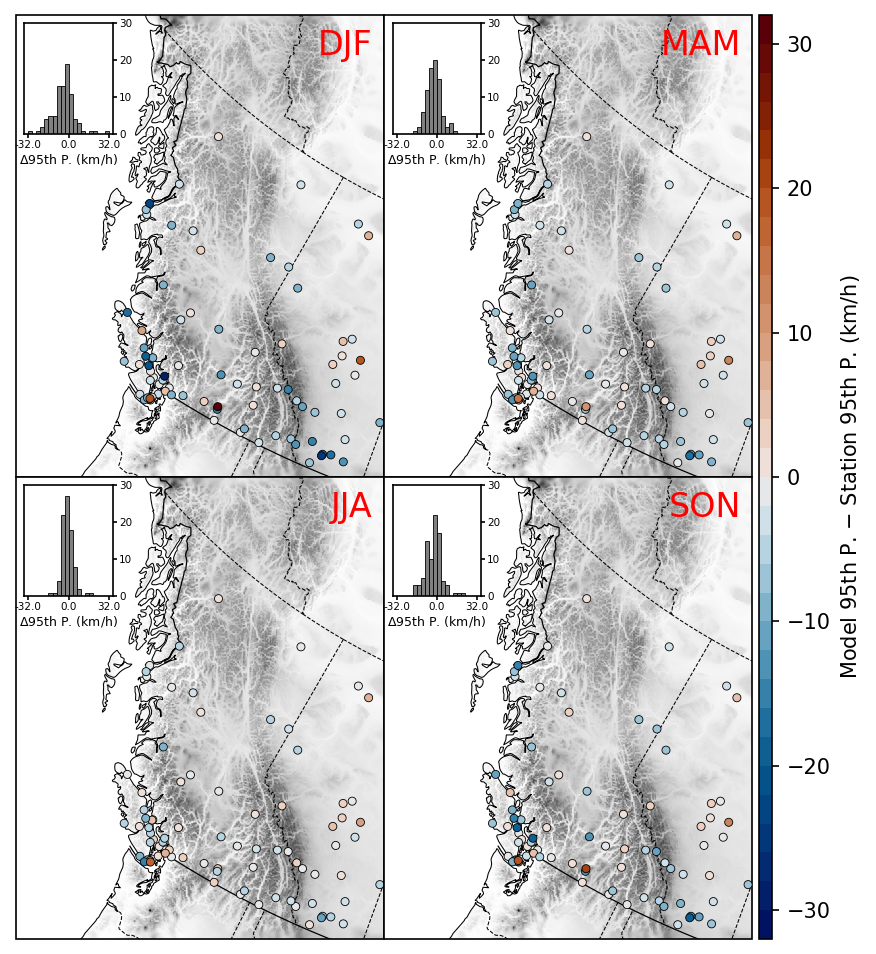

In [16]:
cmap_corr = ListedColormap(cm.lajolla(np.linspace(0, 1, 10)))
cmap_medbias = ListedColormap(cm.vik(np.linspace(0, 1, 28)))
cmap_95pbias = ListedColormap(cm.vik(np.linspace(0, 1, 32)))

plot_seasonal(corr_dict_ubc, cmap_corr, topo=hgt_ubc, hist_bins=np.arange(0, 1+.05, .05), hist_xlabel="Correlation", cbar_label="Correlation", hist_ylim=20.5, hist_yticks=[0, 5, 10, 15, 20])
plot_seasonal(bmedian_dict_ubc, cmap_medbias, topo=hgt_ubc, hist_bins=np.arange(-14,14+1.4,1.4), hist_xlabel=r'$\Delta$Median (km/h)', cbar_label='Model Median $-$ Station Median (km/h)', hist_yticks=[0, 5, 10, 15, 20, 25])
plot_seasonal(b95p_dict_ubc, cmap_95pbias, topo=hgt_ubc, hist_bins=np.arange(-32,32+3.2,3.2), hist_xlabel=r'$\Delta$95th P. (km/h)', cbar_label='Model 95th P. $-$ Station 95th P. (km/h)', hist_yticks=[0, 10, 20, 30])

DJF min=0.22 max=0.83
MAM min=0.24 max=0.81
JJA min=-0.07 max=0.84
SON min=0.31 max=0.84


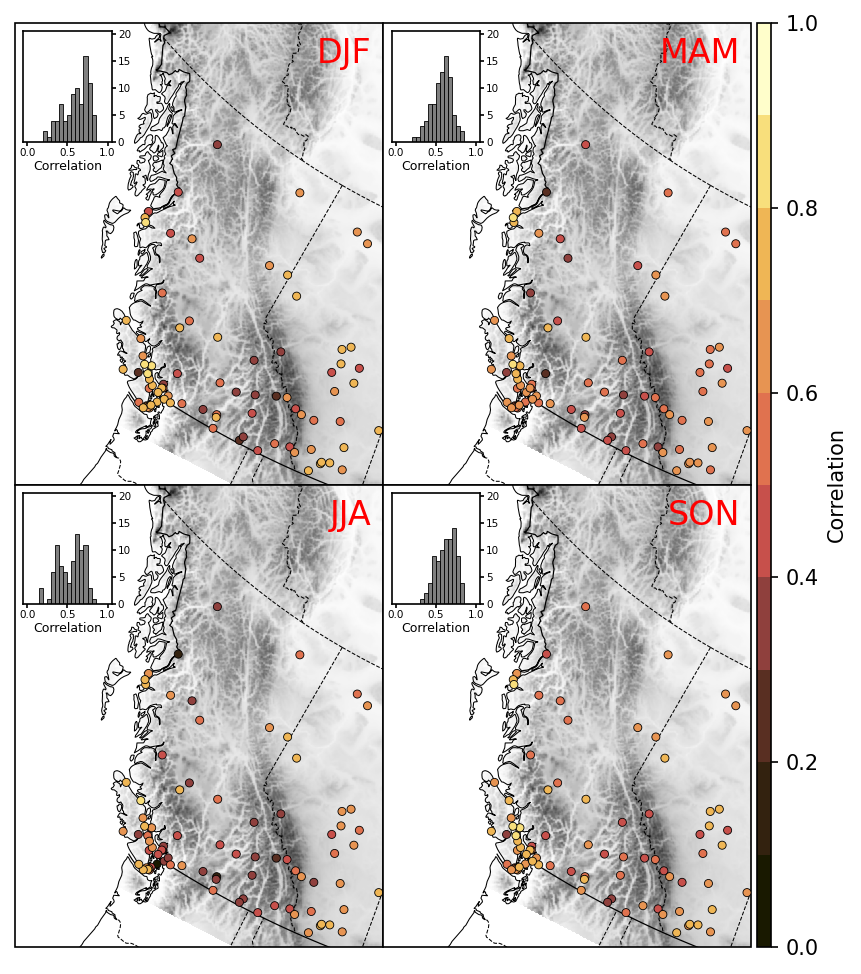

DJF min=-13.89 max=12.71
MAM min=-7.07 max=8.85
JJA min=-7.78 max=8.57
SON min=-7.82 max=10.16


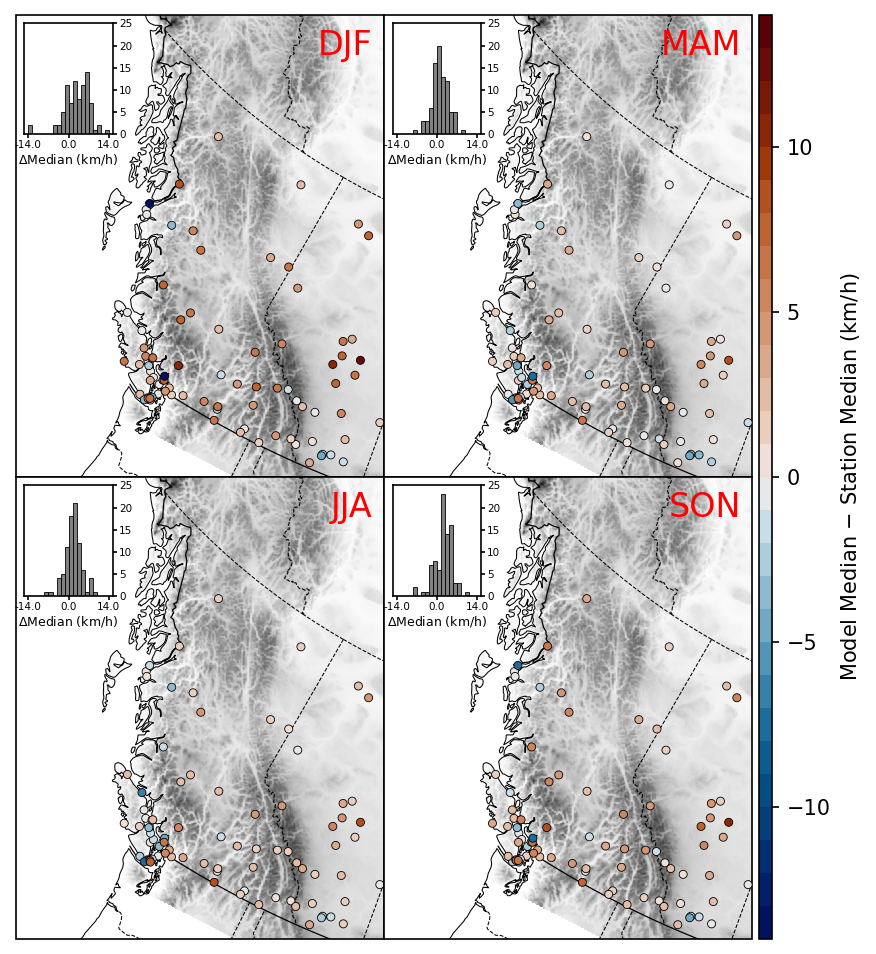

DJF min=-31.62 max=20.12
MAM min=-15.52 max=13.15
JJA min=-14.16 max=13.88
SON min=-19.89 max=15.44


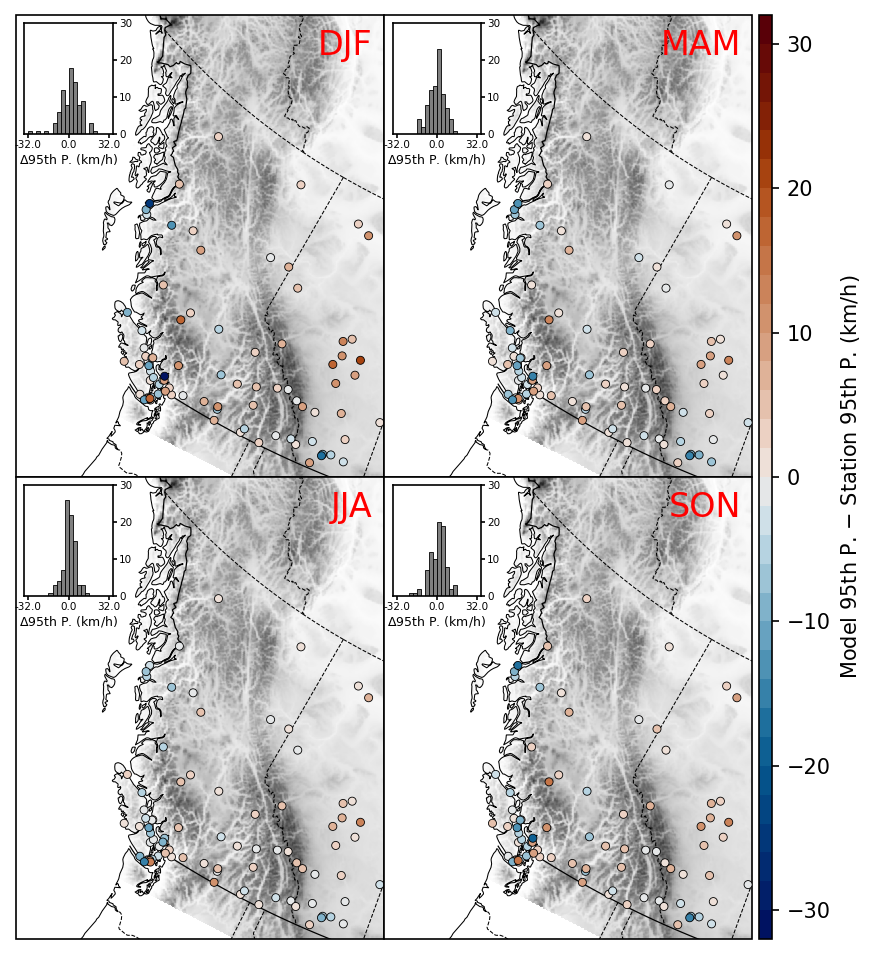

In [17]:
cmap_corr = ListedColormap(cm.lajolla(np.linspace(0, 1, 10)))
cmap_medbias = ListedColormap(cm.vik(np.linspace(0, 1, 28)))
cmap_95pbias = ListedColormap(cm.vik(np.linspace(0, 1, 32)))

plot_seasonal(corr_dict_usask, cmap_corr, topo=hgt_usask, hist_bins=np.arange(0, 1+.05, .05), hist_xlabel="Correlation", cbar_label="Correlation", hist_ylim=20.5, hist_yticks=[0, 5, 10, 15, 20])
plot_seasonal(bmedian_dict_usask, cmap_medbias, topo=hgt_usask, hist_bins=np.arange(-14,14+1.4,1.4), hist_xlabel=r'$\Delta$Median (km/h)', cbar_label='Model Median $-$ Station Median (km/h)', hist_yticks=[0, 5, 10, 15, 20, 25])
plot_seasonal(b95p_dict_usask, cmap_95pbias, topo=hgt_usask, hist_bins=np.arange(-32,32+3.2,3.2), hist_xlabel=r'$\Delta$95th P. (km/h)', cbar_label='Model 95th P. $-$ Station 95th P. (km/h)', hist_yticks=[0, 10, 20, 30])

# Taylor Diagram

In [18]:
# # Set up the plot

# fig = plt.figure(figsize=(6, 6), dpi=120)
# ax = fig.add_subplot(111, polar=True)

# rlim = 2.0
# dr = .5
# ax.set_theta_zero_location('N')
# ax.set_theta_direction(-1)
# ax.set_rlabel_position(225)
# ax.set_ylabel('Standard Deviation (Normalized)')
# ax.set_yticks(np.arange(0, rlim + dr, dr))
# ax.set_ylim(0, rlim)
# ax.set_thetamin(0)
# ax.set_thetamax(90)

# corr_ticklabels = np.array([0,1,2,3,4,5,6,7,8,9,9.5,9.9,10])/10.
# corr_ticks = np.arcsin(corr_ticklabels)
# ax.set_thetagrids(np.degrees(corr_ticks), labels=corr_ticklabels)
# ax.grid(color='grey',linestyle='--')

# for i,diam in enumerate([0.5,1.0,1.5,2.0]):
#     circle = plt.Circle((1, 0), diam, transform=ax.transData._b, color='blue', fill=False, linewidth=1, linestyle=':')
#     ax.add_artist(circle)
#     if i < 2:
#         ax.text(
#             np.pi/2 - .05, 1.+diam, f"{diam:.1f}",
#             color='blue', fontsize=10, ha='center', va='bottom', rotation=0,
#             bbox=dict(facecolor='white', edgecolor='none', boxstyle='round,pad=0.1')
#         )

# ax.text(np.pi/4, rlim - .1, 'Correlation Coefficient', color='k', fontsize=10, rotation=-45, zorder=9)
# ax.text(np.pi/2+.015, .96, '.', color='k', fontsize=40, rotation=0, zorder=9)
# ax.text(np.pi/2+.09, .945, 'Obsv.', color='k', fontsize=7, rotation=0, zorder=9)

# def plot_point(r, theta):
#     ax.scatter(np.pi/2 - theta, r, marker='o', facecolor='red', edgecolor='k', linewidth=.4, zorder=10)


# # Plot the data station by station

# std_norm, rms_norm, corr = [1.], [0.], [1.]

# for i, stn in enumerate(sorted(WS_coverage_dict.keys())):

#     if i < 100:
#         # Get station data
#         print(f"({i+1}/{len(WS_coverage_dict)}) Working on {stn}...")

#         data = get_stn(stn)
#         lat = stn_latlon[stn][0]
#         lon = stn_latlon[stn][1]
#         start_time = data.index.min().to_datetime64()
#         end_time = data.index.max().to_datetime64()
#         stn_humid = data["Wind Spd (km/h)"].resample('D').mean()
#         stn_humid = stn_humid[stn_humid.index < '2023-10-01T00:00:00.000000000']

#         for year, month in BAD_MONTHS:
#             stn_humid = stn_humid[~((stn_humid.index.year == year) & (stn_humid.index.month == month))]

#         # Get model data nearest the station
#         nearest_idx = get_nearest_wrf_point(humid_ds, lat, lon)
#         wrf_humid = humid_ds.isel(south_north=nearest_idx[0], west_east=nearest_idx[1])

#         for year, month in BAD_MONTHS:
#             wrf_humid = wrf_humid.sel(time=~((wrf_humid.time.dt.year == year) & (wrf_humid.time.dt.month == month)))

#         # turn into numpy arrays
#         stn_humid = stn_humid.values
#         wrf_humid = wrf_humid['WS'].values

#         # remove nans
#         wrf_humid = wrf_humid[~np.isnan(stn_humid)]
#         stn_humid = stn_humid[~np.isnan(stn_humid)]

#         # taylor statistics
#         stats = sm.taylor_statistics(wrf_humid, stn_humid)
#         std_norm.append(stats['sdev'][1] / stats['sdev'][0])
#         rms_norm.append(stats['crmsd'][1] / stats['sdev'][0])
#         corr.append(stats['ccoef'][1])
#         if corr[-1] < 0:
#             print(f"WARNING: Negative Correlation Detected for Station {stn}")

#         # plot
#         plot_point(std_norm[-1], np.arccos(corr[-1]))

# plt.show()